# Reading 10X Cell Ranger output directly

If for whatever reason you've decided to skip the reannotation/preprocessing, you can read the files directly from the Cell Ranger output folder with `Dandelion`'s `ddl.read_10x_vdj`, which accepts the `*_contig_annotations.csv` or `all_contig_annotations.json` file(s) as input. If reading with the `.csv` file, and the `.fasta` file and/or `.json` file(s) are in the same folder, `ddl.read_10x_vdj` will try to extract additional information not found in the `.csv` file e.g. contig sequences.

From <b>Cell Ranger V4</b> onwards, there is also an `airr_rearrangement.tsv` file that can be used directly with `Dandelion`. However, doing so will miss out on the reannotation steps but that is entirely up to you.


<b>Import dandelion module</b>

In [1]:
import os
import pandas as pd
import dandelion as ddl

# new function to setup tutorial data
from dandelion.tutorial import setup_dandelion_tutorial_bcr

setup_dandelion_tutorial_bcr()

# change directory to somewhere more workable
os.chdir("dandelion_tutorial")
# ddl.logging.print_versions()
folder_location = "sc5p_v2_hs_PBMC_10k_b"
# or file_location = 'sc5p_v2_hs_PBMC_10k/'
vdj = ddl.read_10x_vdj(folder_location, filename_prefix="filtered")
vdj

Lazy Dandelion object with n_obs = 994 and n_contigs = 2601
    data: cell_id, is_cell_10x, sequence_id, high_confidence_10x, sequence_length_10x, locus, v_call, d_call, j_call, c_call, complete_vdj, productive, junction_aa, junction, consensus_count, umi_count, clone_id, raw_consensus_id_10x, sequence, rearrangement_status
    metadata: cell_id, clone_id, clone_id_rank, locus_VDJ, locus_VJ, v_call_VDJ, v_call_VJ, d_call_VDJ, j_call_VDJ, j_call_VJ, c_call_VDJ, c_call_VJ, junction_aa_VDJ, junction_aa_VJ, junction_VDJ, junction_VJ, umi_count_VDJ, umi_count_VJ, locus_VDJ_main, locus_VJ_main, v_call_VDJ_main, v_call_VJ_main, d_call_VDJ_main, j_call_VDJ_main, j_call_VJ_main, c_call_VDJ_main, c_call_VJ_main, junction_aa_VDJ_main, junction_aa_VJ_main, junction_VDJ_main, junction_VJ_main, umi_count_VDJ_main, umi_count_VJ_main, isotype, isotype_main, isotype_status, locus_status, chain_status, rearrangement_status_VDJ, rearrangement_status_VJ

With `ddl.read_10x_airr`:

In [2]:
# read in the airr_rearrangement.tsv file
file_location = "sc5p_v2_hs_PBMC_10k_b/airr_rearrangement.tsv"
vdj = ddl.read_10x_airr(file_location)
vdj

Lazy Dandelion object with n_obs = 994 and n_contigs = 2093
    data: cell_id, sequence_id, sequence, sequence_aa, productive, rev_comp, v_call, v_cigar, d_call, d_cigar, j_call, j_cigar, c_call, c_cigar, sequence_alignment, germline_alignment, junction, junction_aa, junction_length, junction_aa_length, v_sequence_start, v_sequence_end, d_sequence_start, d_sequence_end, j_sequence_start, j_sequence_end, c_sequence_start, c_sequence_end, consensus_count, umi_count, is_cell, locus, rearrangement_status
    metadata: cell_id, productive_VDJ, productive_VJ, v_call_VDJ, v_call_VJ, d_call_VDJ, j_call_VDJ, j_call_VJ, c_call_VDJ, c_call_VJ, junction_VDJ, junction_VJ, junction_aa_VDJ, junction_aa_VJ, locus_VDJ, locus_VJ, umi_count_VDJ, umi_count_VJ, productive_VDJ_main, productive_VJ_main, v_call_VDJ_main, v_call_VJ_main, d_call_VDJ_main, j_call_VDJ_main, j_call_VJ_main, c_call_VDJ_main, c_call_VJ_main, junction_VDJ_main, junction_VJ_main, junction_aa_VDJ_main, junction_aa_VJ_main, locus_VDJ_ma

If you are using non-10x data e.g. Parse Bioscience Evercode, BD Rhapsody, you can use `ddl.read_parse_airr` and `ddl.read_bd_airr` respectively. If you are using other sources of single-cell AIRR data that provides standard AIRR formatted files e.g. SeekGene Biosciences, or just a standard AIRR file, you can use `ddl.read_airr` directly.

We will continue with the rest of the filtering part of the analysis to show how it slots smoothly with the rest of the workflow.

<b>Import modules for use with scanpy</b>

In [3]:
import scanpy as sc
import warnings

warnings.filterwarnings("ignore")
sc.logging.print_header()

Package,Version
sc-dandelion,1.0.0a1.dev36+dirty (1.0.0a1.dev36)
pandas,2.3.3
scanpy,1.11.5
Component,Info
Python,"3.12.9 | packaged by conda-forge | (main, Mar 4 2025, 22:44:42) [Clang 18.1.8 ]"
OS,macOS-26.3.1-arm64-arm-64bit
CPU,"8 logical CPU cores, arm"
GPU,No GPU found
Updated,2026-05-01 12:10
Dependency,Version


<b>Import the transcriptome data</b>

In [4]:
adata = sc.read_10x_h5(
    "sc5p_v2_hs_PBMC_10k_b/filtered_feature_bc_matrix.h5", gex_only=True
)
adata.obs["sample_id"] = "sc5p_v2_hs_PBMC_10k_b"
adata.var_names_make_unique()
adata

AnnData object with n_obs × n_vars = 10553 × 36601
    obs: 'sample_id'
    var: 'gene_ids', 'feature_types', 'genome', 'pattern', 'read', 'sequence'

Run QC on the transcriptome data.

In [5]:
ddl.pp.recipe_scanpy_qc(adata)
adata

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


AnnData object with n_obs × n_vars = 10553 × 36601
    obs: 'sample_id', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'scrublet_score', 'is_doublet', 'filter_rna'
    var: 'gene_ids', 'feature_types', 'genome', 'pattern', 'read', 'sequence'

Run the filtering of bcr data. Note that I'm using the `DandelionPolars` object as input rather than the pandas dataframe (yes both types of input will works. In fact, a file path to the .tsv will work too).

In [6]:
# The function will return both objects.
vdj, adata = ddl.pp.check_contigs(vdj, adata)

Filtering contigs...
Marking ambiguous contigs...
Initializing DandelionPolars object...


<b>Check the output V(D)J table</b>

The vdj table is returned as a `DandelionPolars` class object in the `.data` slot; if a file was provided for `filter_bcr` above, a new file will be created in the same folder with the `filtered` prefix. Note that this V(D)J table is indexed based on contigs (sequence_id).

In [7]:
vdj

Lazy Dandelion object with n_obs = 984 and n_contigs = 2028
    data: cell_id, sequence_id, sequence, sequence_aa, productive, rev_comp, v_call, v_cigar, d_call, d_cigar, j_call, j_cigar, c_call, c_cigar, sequence_alignment, germline_alignment, junction, junction_aa, junction_length, junction_aa_length, v_sequence_start, v_sequence_end, d_sequence_start, d_sequence_end, j_sequence_start, j_sequence_end, c_sequence_start, c_sequence_end, consensus_count, umi_count, is_cell, locus, rearrangement_status, extra, ambiguous
    metadata: cell_id, productive_VDJ, productive_VJ, v_call_VDJ, v_call_VJ, d_call_VDJ, j_call_VDJ, j_call_VJ, c_call_VDJ, c_call_VJ, junction_VDJ, junction_VJ, junction_aa_VDJ, junction_aa_VJ, locus_VDJ, locus_VJ, umi_count_VDJ, umi_count_VJ, productive_VDJ_main, productive_VJ_main, v_call_VDJ_main, v_call_VJ_main, d_call_VDJ_main, j_call_VDJ_main, j_call_VJ_main, c_call_VDJ_main, c_call_VJ_main, junction_VDJ_main, junction_VJ_main, junction_aa_VDJ_main, junction_aa_VJ_

<b>Check the AnnData object as well</b>

And the `AnnData` object is indexed based on cells.

In [8]:
adata

AnnData object with n_obs × n_vars = 10553 × 36601
    obs: 'sample_id', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'scrublet_score', 'is_doublet', 'filter_rna', 'has_contig', 'productive_VDJ', 'productive_VJ', 'v_call_VDJ', 'v_call_VJ', 'd_call_VDJ', 'j_call_VDJ', 'j_call_VJ', 'c_call_VDJ', 'c_call_VJ', 'junction_VDJ', 'junction_VJ', 'junction_aa_VDJ', 'junction_aa_VJ', 'locus_VDJ', 'locus_VJ', 'umi_count_VDJ', 'umi_count_VJ', 'productive_VDJ_main', 'productive_VJ_main', 'v_call_VDJ_main', 'v_call_VJ_main', 'd_call_VDJ_main', 'j_call_VDJ_main', 'j_call_VJ_main', 'c_call_VDJ_main', 'c_call_VJ_main', 'junction_VDJ_main', 'junction_VJ_main', 'junction_aa_VDJ_main', 'junction_aa_VJ_main', 'locus_VDJ_main', 'locus_VJ_main', 'umi_count_VDJ_main', 'umi_count_VJ_main', 'isotype', 'isotype_main', 'isotype_status', 'locus_status', 'chain_status', 'rearrangement_status_VDJ', 'rearrangement_status_VJ'
    var: 'gene_ids', 'feature_types', 'genome', 'patter

<b>The number of cells that actually has a matching BCR can be tabluated.</b>

In [9]:
pd.crosstab(adata.obs["has_contig"], adata.obs["chain_status"])

chain_status,Extra pair,No_contig,Orphan VDJ,Orphan VJ,Single pair
has_contig,,,,,
No_contig,0,9569,0,0,0
True,81,0,5,16,882


<b>Now actually filter the AnnData object and run through a standard workflow starting by filtering genes and normalizing the data</b>

Because the 'filtered' `AnnData` object was returned as a filtered but otherwise unprocessed object, we still need to normalize and run through the usual process here. The following is just a standard scanpy workflow.

In [10]:
adata = adata[
    adata.obs["filter_rna"] == "False"
]  # from ddl.pp.recipe_scanpy_qc
# filter genes
sc.pp.filter_genes(adata, min_cells=3)
# Normalize the counts
sc.pp.normalize_total(adata, target_sum=1e4)
# Logarithmize the data
sc.pp.log1p(adata)
# Stash the normalised counts
adata.raw = adata

<b>Identify highly-variable genes</b>

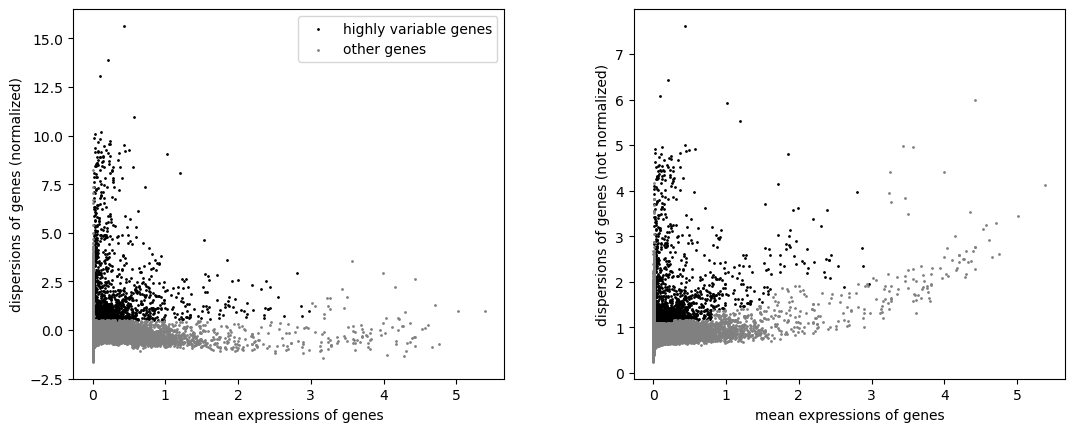

In [11]:
sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)
sc.pl.highly_variable_genes(adata)

<b>Filter the genes to only those marked as highly-variable</b>

In [12]:
adata = adata[:, adata.var.highly_variable]

<b>Regress out effects of total counts per cell and the percentage of mitochondrial genes expressed. Scale the data to unit variance.</b>

In [13]:
sc.pp.regress_out(adata, ["total_counts", "pct_counts_mt"])
sc.pp.scale(adata, max_value=10)

<b>Run PCA</b>

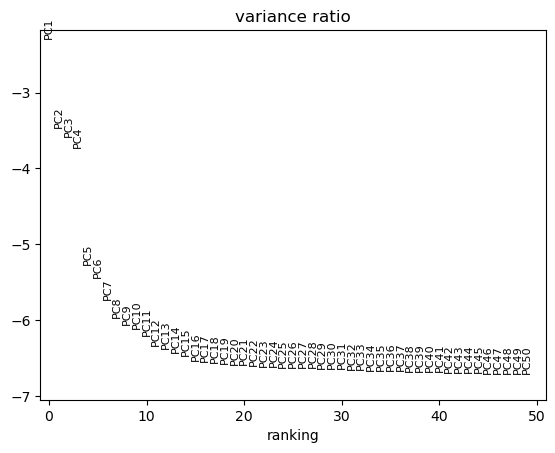

In [14]:
sc.tl.pca(adata, svd_solver="arpack")
sc.pl.pca_variance_ratio(adata, log=True, n_pcs=50)

<b>Computing the neighborhood graph, umap and clusters</b>

In [15]:
# Computing the neighborhood graph
sc.pp.neighbors(adata)
# Embedding the neighborhood graph
sc.tl.umap(adata)
# Clustering the neighborhood graph
sc.tl.leiden(adata)

<b>Visualizing the clusters and whether or not there's a corresponding BCR</b>

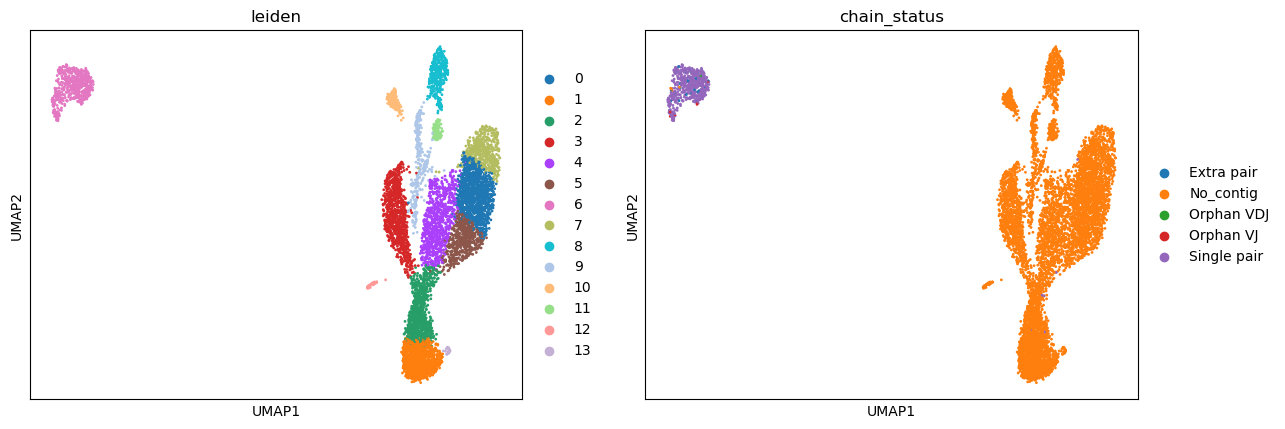

In [16]:
sc.pl.umap(adata, color=["leiden", "chain_status"])

<b>Visualizing some B cell genes</b>

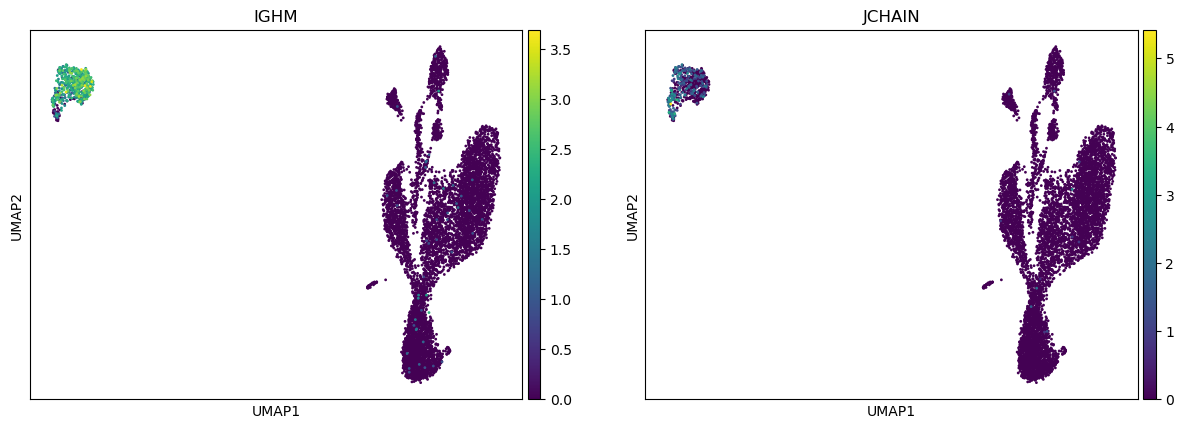

In [17]:
sc.pl.umap(adata, color=["IGHM", "JCHAIN"])

<b>Save AnnData</b>

We can save this `AnnData` object for now.

In [18]:
adata.write("adata2.h5ad", compression="gzip")

<b>Save DandelionPolars</b>

To save the vdj object, we have two options - either save the `.data` and `.metadata` slots with pandas' functions.

</div>

<div class="alert alert-warning">

Polars backend update

Since `vdj.data` is a Polars DataFrame in the polars backend, the pandas `.to_csv()` method is no longer available.
Use Polars' `.write_csv()` instead (note the parameter is `separator=`, not `sep=`).

</div>


In [19]:
vdj.data.collect().write_csv("filtered_vdj_table2.tsv", separator="\t")

In [20]:
vdj.write_h5ddl("dandelion_results2.h5ddl")

### Concatenating multiple bcr objects

It is quite common that one might be trying to analyse data from multiple samples. In that case, `dandelion` has a `concat` function to merge the data.

We will simulate a second object but reading in the same file.

In [21]:
vdj1 = ddl.read_10x_vdj(folder_location, filename_prefix="filtered")
vdj2 = ddl.read_10x_vdj(folder_location, filename_prefix="filtered")

Before you merge the objects, make sure that the "cell_id" and "sequence_id" are distinct so that you can distinguish them later

In [22]:
vdj1.add_cell_prefix("run1_")
vdj2.add_cell_prefix("run2_")

In [23]:
vdj_merged = ddl.tl.concat([vdj1, vdj2])
vdj_merged

Lazy Dandelion object with n_obs = 1988 and n_contigs = 5202
    data: cell_id, is_cell_10x, sequence_id, high_confidence_10x, sequence_length_10x, locus, v_call, d_call, j_call, c_call, complete_vdj, productive, junction_aa, junction, consensus_count, umi_count, clone_id, raw_consensus_id_10x, sequence, rearrangement_status
    metadata: cell_id, clone_id, clone_id_rank, locus_VDJ, locus_VJ, v_call_VDJ, v_call_VJ, d_call_VDJ, j_call_VDJ, j_call_VJ, c_call_VDJ, c_call_VJ, junction_aa_VDJ, junction_aa_VJ, junction_VDJ, junction_VJ, umi_count_VDJ, umi_count_VJ, locus_VDJ_main, locus_VJ_main, v_call_VDJ_main, v_call_VJ_main, d_call_VDJ_main, j_call_VDJ_main, j_call_VJ_main, c_call_VDJ_main, c_call_VJ_main, junction_aa_VDJ_main, junction_aa_VJ_main, junction_VDJ_main, junction_VJ_main, umi_count_VDJ_main, umi_count_VJ_main, isotype, isotype_main, isotype_status, locus_status, chain_status, rearrangement_status_VDJ, rearrangement_status_VJ

In [24]:
vdj_merged.data.collect()

cell_id,is_cell_10x,sequence_id,high_confidence_10x,sequence_length_10x,locus,v_call,d_call,j_call,c_call,complete_vdj,productive,junction_aa,junction,consensus_count,umi_count,clone_id,raw_consensus_id_10x,sequence,rearrangement_status
str,bool,str,bool,i64,str,str,str,str,str,bool,bool,str,str,i64,i64,str,str,str,str
"""run1_AAACCTGTCATATCGG-1""",true,"""run1_AAACCTGTCATATCGG-1_contig…",true,556,"""IGK""","""IGKV1-8""",null,"""IGKJ4""","""IGKC""",true,true,"""CQQYDELPVTF""","""TGTCAACAATATGACGAACTTCCCGTCACT…",9139,68,"""clonotype9""","""clonotype9_consensus_1""","""TGGGGAGGAGTCAGTCCCAACCAGGACACG…","""Standard"""
"""run1_AAACCTGTCATATCGG-1""",true,"""run1_AAACCTGTCATATCGG-1_contig…",true,802,"""IGK""",null,null,"""IGKJ1""",null,false,false,null,null,88,7,"""clonotype9""",null,"""GGCTGCTATCTTCTCTTTCTCTCAAGGAAG…","""Unknown"""
"""run1_AAACCTGTCCGTTGTC-1""",true,"""run1_AAACCTGTCCGTTGTC-1_contig…",true,565,"""IGH""","""IGHV1-69D""","""IGHD3-22""","""IGHJ3""","""IGHM""",true,true,"""CATTYYYDSSGYYQNDAFDIW""","""TGTGCGACTACGTATTACTATGATAGTAGT…",4161,51,"""clonotype10""","""clonotype10_consensus_2""","""ATCACATAACAACCACATTCCTCCTCTAAA…","""Standard"""
"""run1_AAACCTGTCCGTTGTC-1""",true,"""run1_AAACCTGTCCGTTGTC-1_contig…",true,551,"""IGK""","""IGKV1-8""",null,"""IGKJ1""","""IGKC""",true,true,"""CQQYYSYPRTF""","""TGTCAACAGTATTATAGTTACCCTCGGACG…",5679,43,"""clonotype10""","""clonotype10_consensus_1""","""AGGAGTCAGACCCTGTCAGGACACAGCATA…","""Standard"""
"""run1_AAACCTGTCGAGAACG-1""",true,"""run1_AAACCTGTCGAGAACG-1_contig…",true,642,"""IGL""","""IGLV5-45""",null,"""IGLJ3""","""IGLC3""",true,true,"""CMIWHSSAWVV""","""TGTATGATTTGGCACAGCAGCGCTTGGGTG…",13160,90,"""clonotype11""","""clonotype11_consensus_1""","""ACTGTGGGGGTAAGAGGTTGTGTCCACCAT…","""Standard"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""run2_TTTGGTTTCAGTGTTG-1""",true,"""run2_TTTGGTTTCAGTGTTG-1_contig…",true,640,"""IGL""","""IGLV2-23""",null,"""IGLJ2""","""IGLC2""",true,true,"""CCSYAGSSTFEVF""","""TGCTGCTCATATGCAGGTAGTAGCACTTTC…",6497,58,"""clonotype983""","""clonotype983_consensus_1""","""GGGGTCACAAGAGGCAGCGCTCTCGGGACG…","""Standard"""
"""run2_TTTGGTTTCAGTGTTG-1""",true,"""run2_TTTGGTTTCAGTGTTG-1_contig…",true,517,"""IGH""","""IGHV2-5""",null,"""IGHJ4""","""IGHM""",true,true,"""CAHRFEYFDYW""","""TGTGCACACAGGTTTGAGTACTTTGACTAC…",3530,33,"""clonotype983""","""clonotype983_consensus_2""","""ATATTTCGTATCTGGGGAGTGACTCCTGTG…","""Standard"""
"""run2_TTTGGTTTCGGTGTCG-1""",true,"""run2_TTTGGTTTCGGTGTCG-1_contig…",true,568,"""IGK""","""IGKV3-11""",null,"""IGKJ4""","""IGKC""",true,true,"""CQQRSNWPRLTF""","""TGTCAGCAGCGTAGCAACTGGCCTAGGCTC…",3058,22,"""clonotype984""","""clonotype984_consensus_2""","""GGGAGAGCCCTGGGGAGGAACTGCTCAGTT…","""Standard"""


In [25]:
vdj_merged.metadata.collect()

cell_id,clone_id,clone_id_rank,locus_VDJ,locus_VJ,v_call_VDJ,v_call_VJ,d_call_VDJ,j_call_VDJ,j_call_VJ,c_call_VDJ,c_call_VJ,junction_aa_VDJ,junction_aa_VJ,junction_VDJ,junction_VJ,umi_count_VDJ,umi_count_VJ,locus_VDJ_main,locus_VJ_main,v_call_VDJ_main,v_call_VJ_main,d_call_VDJ_main,j_call_VDJ_main,j_call_VJ_main,c_call_VDJ_main,c_call_VJ_main,junction_aa_VDJ_main,junction_aa_VJ_main,junction_VDJ_main,junction_VJ_main,umi_count_VDJ_main,umi_count_VJ_main,isotype,isotype_main,isotype_status,locus_status,chain_status,rearrangement_status_VDJ,rearrangement_status_VJ
str,str,cat,str,str,str,str,str,str,str,str,str,str,str,str,str,i64,i64,str,str,str,str,str,str,str,str,str,str,str,str,str,f64,f64,str,str,str,str,str,str,str
"""run1_AAACCTGTCATATCGG-1""","""clonotype9""","""636""",null,"""IGK""",null,"""IGKV1-8""",null,null,"""IGKJ4""",null,"""IGKC""",null,"""CQQYDELPVTF""",null,"""TGTCAACAATATGACGAACTTCCCGTCACT…",0,68,null,"""IGK""",null,"""IGKV1-8""",null,null,"""IGKJ4""",null,"""IGKC""",null,"""CQQYDELPVTF""",null,"""TGTCAACAATATGACGAACTTCCCGTCACT…",null,68.0,null,null,null,"""Orphan IGK""","""Orphan VJ""",null,"""Standard"""
"""run1_AAACCTGTCCGTTGTC-1""","""clonotype10""","""979""","""IGH""","""IGK""","""IGHV1-69D""","""IGKV1-8""","""IGHD3-22""","""IGHJ3""","""IGKJ1""","""IGHM""","""IGKC""","""CATTYYYDSSGYYQNDAFDIW""","""CQQYYSYPRTF""","""TGTGCGACTACGTATTACTATGATAGTAGT…","""TGTCAACAGTATTATAGTTACCCTCGGACG…",51,43,"""IGH""","""IGK""","""IGHV1-69D""","""IGKV1-8""","""IGHD3-22""","""IGHJ3""","""IGKJ1""","""IGHM""","""IGKC""","""CATTYYYDSSGYYQNDAFDIW""","""CQQYYSYPRTF""","""TGTGCGACTACGTATTACTATGATAGTAGT…","""TGTCAACAGTATTATAGTTACCCTCGGACG…",51.0,43.0,"""IgM""","""IgM""","""IgM""","""IGH + IGK""","""Single pair""","""Standard""","""Standard"""
"""run1_AAACCTGTCGAGAACG-1""","""clonotype11""","""329""","""IGH""","""IGL""","""IGHV1-2""","""IGLV5-45""",null,"""IGHJ3""","""IGLJ3""","""IGHM""","""IGLC3""","""CAREIEGDGVFEIW""","""CMIWHSSAWVV""","""TGTGCGAGAGAGATAGAGGGGGACGGTGTT…","""TGTATGATTTGGCACAGCAGCGCTTGGGTG…",47,90,"""IGH""","""IGL""","""IGHV1-2""","""IGLV5-45""",null,"""IGHJ3""","""IGLJ3""","""IGHM""","""IGLC3""","""CAREIEGDGVFEIW""","""CMIWHSSAWVV""","""TGTGCGAGAGAGATAGAGGGGGACGGTGTT…","""TGTATGATTTGGCACAGCAGCGCTTGGGTG…",47.0,90.0,"""IgM""","""IgM""","""IgM""","""IGH + IGL""","""Single pair""","""Standard""","""Standard"""
"""run1_AAACCTGTCTTGAGAC-1""","""clonotype12""","""456""","""IGH""","""IGK""","""IGHV5-51""","""IGKV1D-8""",null,"""IGHJ3""","""IGKJ2""","""IGHM""","""IGKC""","""CARHIRGNRFGNDAFDIW""","""CQQYYSFPYTF""","""TGTGCGAGACATATCCGTGGGAACAGATTT…","""TGTCAACAGTATTATAGTTTCCCGTACACT…",80,22,"""IGH""","""IGK""","""IGHV5-51""","""IGKV1D-8""",null,"""IGHJ3""","""IGKJ2""","""IGHM""","""IGKC""","""CARHIRGNRFGNDAFDIW""","""CQQYYSFPYTF""","""TGTGCGAGACATATCCGTGGGAACAGATTT…","""TGTCAACAGTATTATAGTTTCCCGTACACT…",80.0,22.0,"""IgM""","""IgM""","""IgM""","""IGH + IGK""","""Single pair""","""Standard""","""Standard"""
"""run1_AAACGGGAGCGACGTA-1""","""clonotype13""","""947""","""IGH""","""IGL""","""IGHV4-59""","""IGLV3-19""",null,"""IGHJ3""","""IGLJ2""","""IGHM""","""IGLC2""","""CARVGYRAAAGTDAFDIW""","""CNSRDSSGNHVVF""","""TGTGCGAGAGTAGGCTATAGAGCAGCAGCT…","""TGTAACTCCCGGGACAGCAGTGGTAACCAT…",18,14,"""IGH""","""IGL""","""IGHV4-59""","""IGLV3-19""",null,"""IGHJ3""","""IGLJ2""","""IGHM""","""IGLC2""","""CARVGYRAAAGTDAFDIW""","""CNSRDSSGNHVVF""","""TGTGCGAGAGTAGGCTATAGAGCAGCAGCT…","""TGTAACTCCCGGGACAGCAGTGGTAACCAT…",18.0,14.0,"""IgM""","""IgM""","""IgM""","""IGH + IGL""","""Single pair""","""Standard""","""Standard"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""run2_TTTGCGCTCTAACGGT-1""","""clonotype980""","""76""","""IGH""","""IGL""","""IGHV3-43""","""IGLV2-8""",null,"""IGHJ6""","""IGLJ3""","""IGHM""","""IGLC2""","""CARVSGSYQYNYYYGMDVW""","""CGSFAGSNIWVF""","""TGTGCAAGAGTAAGTGGGAGCTACCAATAT…","""TGCGGCTCATTTGCAGGCAGCAACATTTGG…",46,163,"""IGH""","""IGL""","""IGHV3-43""","""IGLV2-8""",null,"""IGHJ6""","""IGL